## 1. Import Libraries & Dependencies

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load the Dataset

In [3]:
data_train = pd.read_csv("mnist_train.csv")
data_test = pd.read_csv("mnist_test.csv")

## 3. Convert DataFrames to NumPy Arrays

In [4]:
data_train = data_train.to_numpy()
data_test = data_test.to_numpy()

In [5]:
data_train.shape

(60000, 785)

In [6]:
data_test.shape

(10000, 785)

## 5. Feature and Target Splitting ($X$ / $y$ Split)

In [7]:
X_train = data_train[:,1:]
y_train = data_train[:,0]
X_test = data_test[:,1:]
y_test = data_test[:,0]

## 6. Data Visualization & Sample Inspection

In [8]:
first_image = data_train[0][1:].reshape(28,28)
data_train[0][0]

np.int64(5)

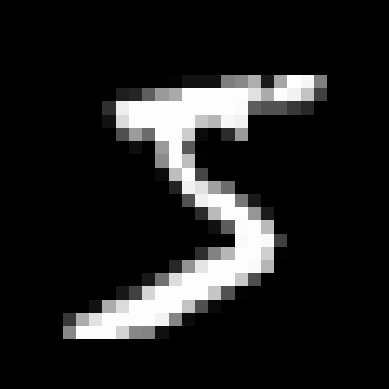

In [9]:
plt.imshow(first_image, cmap='gray')
plt.axis('off')
plt.show()

## resape

In [10]:
X_train = X_train.reshape(-1,1,28,28)
X_test = X_test.reshape(-1,1,28,28)

In [11]:
X_train.shape

(60000, 1, 28, 28)

## Zero-center

In [12]:
mean_image = np.mean(X_test,axis=0)
X_train = X_train - mean_image
X_test = X_test - mean_image

## ReLU

In [13]:
def relu(x):
    return np.maximum(0,x)

## Padding

In [14]:
def padding(x,pad = 1):

    num_row = x.shape[2]
    num_column = x.shape[3]

    new_column = num_column + 2*pad
    new_row = num_row + 2*pad

    zeros = np.zeros((x.shape[0],1,new_row,new_column))
    print(zeros.shape)
    for i in range(x.shape[0]):
        zeros[i,0,pad:pad+num_row,pad:pad + num_column] = x[i,0]

    return zeros

In [15]:
def padding_with_numpy(x,pad = 1):
    return np.pad(x,((0,0),(0,0),(pad,pad),(pad,pad)),mode='constant',constant_values=0)

In [16]:
matrix_test = np.arange(24000).reshape(60,1,20,20)

In [17]:
ft = np.array([[0,1,0],
                  [0,1,0],
                  [0,1,0]])


In [18]:
ft

array([[0, 1, 0],
       [0, 1, 0],
       [0, 1, 0]])

In [19]:
matrix_test.shape

(60, 1, 20, 20)

### vanilla convolution

In [20]:
def vanilla_conv(x,filters,stride =1):

    out_row = int(np.floor((x.shape[2]-filters.shape[0])/stride) + 1)
    out_col = int(np.floor((x.shape[3]-filters.shape[0])/stride) + 1)
    empty = np.zeros((x.shape[0],x.shape[1],out_row,out_col))
    for i in range(x.shape[0]):
        for j in range(out_row):
            for k in range(out_col):
                empty[i,0,j,k] = np.einsum('ij,ij->',x[i,0,j:j+filters.shape[0],k:k+filters.shape[0]],filters)

    return empty

 ### vanilla max Pooling

In [21]:
def vanilla_maxpool(max_pool_input,size_filter = 2 ,stride = 1):

    row_size = max_pool_input.shape[2]
    output_size = int((row_size - size_filter)//stride) +1
    output_maxpool = np.zeros((max_pool_input.shape[0],1,output_size,output_size))

    for i in range(max_pool_input.shape[0]):
        for j in range(output_size):
            for k in range(output_size):
                h_start = j * stride
                v_start = k * stride
                output_maxpool[i,0,j,k] = np.max(max_pool_input[i,0,h_start:h_start+size_filter,v_start:v_start+size_filter])
    return output_maxpool

## im2col

### convolution with im2col

In [41]:
def conv(input_conv,filters,stride =1):
    number_of_input = input_conv.shape[0]
    number_of_row = input_conv.shape[2]
    size_filter = filters.shape[0]

    output_size = int((number_of_row - size_filter)//stride + 1)

    temp_matrix = np.zeros((number_of_input , size_filter ** 2 , output_size ** 2))
    print(temp_matrix.shape)

    for i in range( number_of_input):

        for j in range(output_size):
            for k in range(output_size):

                h_start = j * stride
                v_start = k * stride

                temp_matrix[i,:,j * output_size + k] = (input_conv[
                i,
                0,
                h_start : h_start + size_filter,
                v_start : v_start + size_filter ].flatten())

    output_conv = ((np.expand_dims(filters.flatten(),axis=0))@temp_matrix).reshape(number_of_input,1 ,output_size,output_size)


    return output_conv

### max pooling

In [49]:
def maxpool(input_conv,size_filter = 2,stride =2):
    number_of_input = input_conv.shape[0]
    number_of_row = input_conv.shape[2]
    size_filter = size_filter

    output_size = int((number_of_row - size_filter)//stride + 1)

    temp_matrix = np.zeros((number_of_input , size_filter ** 2 , output_size ** 2))

    for i in range( number_of_input):
        for j in range(output_size):
            for k in range(output_size):

                h_start = j * stride
                v_start = k * stride

                temp_matrix[i,:,j * output_size + k] = (input_conv[
                i,
                0,
                h_start : h_start + size_filter,
                v_start : v_start + size_filter ].flatten())

    output_maxpool = ((np.max(temp_matrix,axis=1)).reshape(number_of_input,1 ,output_size,output_size))


    return output_maxpool

In [50]:
x = maxpool(matrix_test,2,2)

In [51]:
x.shape

(60, 1, 10, 10)